# ESOL dataset exploration

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from dataset_util import load_esol

In [2]:
# load
dataset = load_esol(root='../data/')
print(f'dataset size: {len(dataset)}')
print(f'node features: {dataset.num_node_features}')
print(f'edge features: {dataset.num_edge_features}')

dataset size: 1128
node features: 9
edge features: 3


## sample graph

In [3]:
# look at one molecule
sample = dataset[0]
print(sample)
print(f'smiles: {sample.smiles}')
print(f'target (log S): {sample.y.item():.3f}')
print(f'num atoms: {sample.x.shape[0]}')
print(f'num bonds (edges/2): {sample.edge_index.shape[1] // 2}')

Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])
smiles: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
target (log S): -0.770
num atoms: 32
num bonds (edges/2): 34


In [4]:
# node feature matrix for this molecule
print('node features shape:', sample.x.shape)
print(sample.x)

node features shape: torch.Size([32, 9])
tensor([[8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 0],
        [6, 0, 2, 5, 0, 0, 2, 0, 0],
        [7, 0, 1, 5, 0, 0, 2, 0, 0],
        [6, 0, 3, 5, 0, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0

## target distribution

In [5]:
targets = torch.tensor([d.y.item() for d in dataset])
print(f'mean: {targets.mean():.3f}')
print(f'std:  {targets.std():.3f}')
print(f'min:  {targets.min():.3f}')
print(f'max:  {targets.max():.3f}')

mean: -3.050
std:  2.096
min:  -11.600


max:  1.580


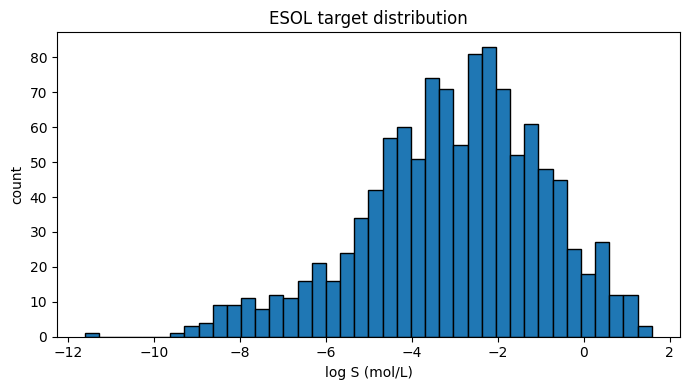

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(targets.numpy(), bins=40, edgecolor='black')
plt.xlabel('log S (mol/L)')
plt.ylabel('count')
plt.title('ESOL target distribution')
plt.tight_layout()
plt.show()

## graph sizes

atoms per molecule — min: 1, max: 55, mean: 13.3


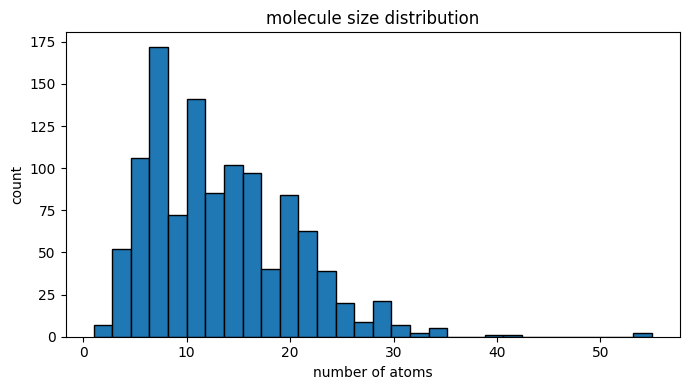

In [7]:
# atoms per molecule
num_atoms = [d.x.shape[0] for d in dataset]
print(f'atoms per molecule — min: {min(num_atoms)}, max: {max(num_atoms)}, mean: {np.mean(num_atoms):.1f}')

plt.figure(figsize=(7, 4))
plt.hist(num_atoms, bins=30, edgecolor='black')
plt.xlabel('number of atoms')
plt.ylabel('count')
plt.title('molecule size distribution')
plt.tight_layout()
plt.show()

## some smiles + targets

In [8]:
for i in range(8):
    d = dataset[i]
    print(f'{d.smiles:<45s}  log S = {d.y.item():.3f}')

OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O   log S = -0.770
Cc1occc1C(=O)Nc2ccccc2                         log S = -3.300
CC(C)=CCCC(C)=CC(=O)                           log S = -2.060
c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43             log S = -7.870
c1ccsc1                                        log S = -1.330
c2ccc1scnc1c2                                  log S = -1.500
Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl             log S = -7.320
CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O               log S = -5.030
